In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
import yt
yt.set_log_level('error')
import os
from dotenv import dotenv_values
import glob
import pandas as pd
import re
from scipy.stats import linregress
import matplotlib.cm as cm
from distinctipy import distinctipy


In [33]:
def read_SF(base_filename, N_seeds, zeroes = False):
    print("base_filename: ", base_filename, flush = True)
    ts_list = []
    for i in range(N_seeds):
        # run_dir = f"SF_WENO5_32_1em4_cell_depth_1em5_ts_false_seed_{i+1}"
        if zeroes:
            run_dir = f"{base_filename}_{i+1}00"
        else:
            run_dir = f"{base_filename}_{i+1}"
        plt_dir = os.path.join(run_dir, "plt_SF_mag0*")
        plotfile_paths = sorted(glob.glob(plt_dir))
        # plotfile_paths = sorted(glob.glob("plt_SF_mag0*"))
        
        
        print(f"Found {len(plotfile_paths)} plotfiles in {run_dir}.")
        
        ts = yt.DatasetSeries(plotfile_paths)
        ts_list.append(ts)
    
        # if i == 0:
        #     first_ds = ts[0]
        #     print("\nAvailable variables in the plotfiles:")
        #     for field in first_ds.field_list:
        #         print(f" - {field[1]}") 
    return ts_list #, first_ds

In [34]:
# run_dir = "SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_1"
N_seeds = 2

# base_filename_3p9em4 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_seed"

# ts_list_3p9em4, _ = read_SF(base_filename_3p9em4, N_seeds)

# base_filename_7p8em4 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_dt_7p8em4_seed"

# ts_list_7p8em4, first_ds = read_SF(base_filename_7p8em4, N_seeds)

# base_filename_1p56em3 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_dt_1p56em3_seed"

# ts_list_1p56em3, _ = read_SF(base_filename_1p56em3, N_seeds, zeroes = True)


# base_filename_1p56em2 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_dt_1p56em2_seed"

# ts_list_1p56em2, _ = read_SF(base_filename_1p56em2, N_seeds, zeroes = True)

# base_filename_1p56em1 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_dt_1p56em1_seed"

# ts_list_1p56em1, _ = read_SF(base_filename_1p56em1, N_seeds, zeroes = True)

# base_filename_1p56 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_dt_1p56_seed"

# ts_list_1p56, _ = read_SF(base_filename_1p56, N_seeds, zeroes = True)

# base_filename_7p8em1 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_dt_7p8em1_seed"

# ts_list_7p8em1, _ = read_SF(base_filename_7p8em1, N_seeds, zeroes = True)


N_dt = 1
# base_filename_arr = ["SF_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_1p56em1_seed", 
#                      "SF_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_1p56em2_seed", 
#                      "SF_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_7p8em3_seed",
#                      "SF_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_3p9em3_seed"]
# dt_arr = ["1.56e-1", "1.56e-2", "7.8e-3", "3.9e-3"]

# base_filename_arr = ["SF_WENO5_new_stoch_32_1em4_cell_depth_1em5_ts_false_dt_1p56em1_seed"]
# base_filename_arr = ["SF_WENO5_single_flux_sqrt2_32_1em4_cell_depth_1em5_ts_false_dt_1p56em1_seed"]
# base_filename_arr = ["SF_WENO5_32_1em4_cell_depth_1em5_ts_false_dt_7p8em4_seed"]

base_filename_arr = ["SF_RK3_Pressure_False_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_3p9em3_seed"]

# base_filename_arr = ["SF_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_7p8em3_seed"]

# dt_arr = ["1.56e-1"]
dt_arr = ["3.9e-3"]

ts_list_arr = []
for n in range(N_dt):
    base_filename = base_filename_arr[n]
    ts_list = read_SF(base_filename, N_seeds, zeroes = True)
    ts_list_arr.append(ts_list)
    

base_filename:  SF_RK3_Pressure_False_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_3p9em3_seed
Found 12 plotfiles in SF_RK3_Pressure_False_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_3p9em3_seed_100.
Found 11 plotfiles in SF_RK3_Pressure_False_WENO5_64_1em4_cell_depth_4em5_ts_false_dt_3p9em3_seed_200.


In [35]:
# # run_dir_2 = "SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_2"
# run_dir_2 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_seed_2"
# plt_dir_2 = os.path.join(run_dir_2, "plt_SF_mag0*")
# plotfile_paths_2 = sorted(glob.glob(plt_dir_2))
# ts_2 = yt.DatasetSeries(plotfile_paths_2)

# # run_dir_3 = "SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_3"
# run_dir_3 = "SF_WENO5_32_1em4_cell_depth_1em5_ts_false_seed_3"
# plt_dir_3 = os.path.join(run_dir_3, "plt_SF_mag0*")
# plotfile_paths_3 = sorted(glob.glob(plt_dir_3))
# ts_3 = yt.DatasetSeries(plotfile_paths_3)
# print(f"Found {len(plotfile_paths_3)} plotfiles in {plt_dir_3}.")

In [36]:
def structure_factor_helper(ax, data, title, cmap='RdBu', fontsize=13):
    """Plot structure factor data with colorbar on top in separated axes"""
    plot_height, plot_bottom = 0.75, 0.05
    cbar_height, cbar_bottom = 0.04, 0.85
    plot_width, plot_left = 0.90, 0.075  
    
    pbbox = transforms.Bbox.from_bounds(plot_left, plot_bottom, plot_width, plot_height)
    cbbox = transforms.Bbox.from_bounds(plot_left, cbar_bottom, plot_width, cbar_height)
    
    to_axes_bbox = transforms.BboxTransformTo(ax.get_position())
    paxes = ax.figure.add_axes(pbbox.transformed(to_axes_bbox))
    caxes = ax.figure.add_axes(cbbox.transformed(to_axes_bbox))
    ax.axis('off')
    
    Ny, Nx = data.shape
    extent = [-Nx/2, Nx/2, -Ny/2, Ny/2]  
    
    # vmax = np.max(np.abs(data))
    # im = paxes.imshow(data, cmap=cmap, origin='lower', extent=extent, aspect=1, 
    #                   norm=SymLogNorm(linthresh=1e-15, vmin=-vmax, vmax=vmax, base=10))

    vmax = data.max()
    # vmax = 3e-13
    # im = paxes.imshow(data, cmap=cmap, origin='lower', extent=extent, aspect=1, norm=LogNorm(vmin=1e-16, vmax=vmax))
    im = paxes.imshow(data, cmap=cmap, origin='lower', extent=extent, aspect=1, vmin=0, vmax=vmax)
    
    paxes.set_xlabel('$k_x$', fontsize=fontsize)
    paxes.set_ylabel('$k_y$', fontsize=fontsize)
    paxes.tick_params(length=0, width=0, labelsize=fontsize-2)
    
    caxes.text(0.5, 3.1, title, transform=caxes.transAxes, 
               ha='center', va='bottom', fontsize=fontsize)
    
    cbar = plt.colorbar(im, cax=caxes, orientation='horizontal')
    cbar.outline.set_visible(False)
    caxes.xaxis.set_ticks_position('top')
    cbar.ax.tick_params(labelsize=fontsize-2)
    
    return paxes, caxes


yt.funcs.mylog.setLevel(40)
# Nx, Ny = first_ds.domain_dimensions[:2]
# Nx, Ny = 64, 64
Nx, Ny = 32, 32
nrows, ncols = 1, 2
# cmap = 'magma'
# cmap = 'Blues'
cmap = 'RdBu'
for i in range(55, len(ts_list_arr[-1][0])):
    ds = ts_list_arr[-1][0][i]
    cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=[Nx, Ny, 1])
    
    S_xx = np.array(cg['struct_fact_velx_velx'][:, :, 0].v)
    S_yy = np.array(cg['struct_fact_vely_vely'][:, :, 0].v)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6), dpi=150)
    fig.suptitle(f'Run A Structure Factor | t = {ds.current_time.v:.5e} and dt = {dt_arr[-1]}', fontsize=15, y=0.94)
    
    structure_factor_helper(axes[0], S_xx.T, r'$S_{u_x, u_x}(\mathbf{k})$', cmap = cmap)
    structure_factor_helper(axes[1], S_yy.T, r'$S_{u_y, u_y}(\mathbf{k})$', cmap = cmap)
    
    plt.show()

In [37]:
def df_trace_f(ts):
    # Get domain dimensions
    Nx, Ny = ts[0].domain_dimensions[:2]
    
    # Initialize lists to store our data
    times = []
    traces = []
    
    
    # Loop over the time series
    for ds in ts:
        # Get the physical simulation time
        sim_time = ds.current_time.v
        
        # Extract the 2D arrays using covering_grid
        cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=[Nx, Ny, 1])
        S_xx = np.array(cg['struct_fact_velx_velx'][:, :, 0].v)
        S_yy = np.array(cg['struct_fact_vely_vely'][:, :, 0].v)
        
        # Calculate the trace (sum of diagonals)
        # We sum over the entire k-space array to get the total energy trace for this timestep
        trace_val = np.sum(S_xx + S_yy)
        
        # Append to lists
        times.append(sim_time)
        traces.append(trace_val)
    
    # Create the Pandas DataFrame
    df_trace = pd.DataFrame({
        'Time': times,
        'Trace': traces
    })

    return df_trace

# Display the first few rows
# print(df_trace)

# df_trace_list_7p8em4 = []
# df_trace_list_3p9em4 = []
# df_trace_list_1p56em3 = []
# df_trace_list_1p56em2 = []
# df_trace_list_1p56em1 = []
# df_trace_list_1p56 = []
# df_trace_list_7p8em1 = []

df_trace_list_arr = []
for n in range(N_dt):
    print(f"n = {n}", flush = True)
    df_trace_list = []
    for i in range(N_seeds):
        print(f"Seed = {i+1}", flush = True)
        df_trace = df_trace_f(ts_list_arr[n][i])
        df_trace_list.append(df_trace)
        
        # df_trace_7p8em4 = df_trace_f(ts_list_7p8em4[i])
        # df_trace_list_7p8em4.append(df_trace_7p8em4)
    
        # df_trace_3p9em4 = df_trace_f(ts_list_3p9em4[i])
        # df_trace_list_3p9em4.append(df_trace_3p9em4)
    
        # df_trace_1p56em3 = df_trace_f(ts_list_1p56em3[i])
        # df_trace_list_1p56em3.append(df_trace_1p56em3)
    
        # df_trace_1p56em2 = df_trace_f(ts_list_1p56em2[i])
        # df_trace_list_1p56em2.append(df_trace_1p56em2)
    
        # df_trace_1p56em1 = df_trace_f(ts_list_1p56em1[i])
        # df_trace_list_1p56em1.append(df_trace_1p56em1)
    
        # df_trace_1p56 = df_trace_f(ts_list_1p56[i])
        # df_trace_list_1p56.append(df_trace_1p56)
    
        # df_trace_7p8em1 = df_trace_f(ts_list_7p8em1[i])
        # df_trace_list_7p8em1.append(df_trace_7p8em1)
        
    df_trace_list_arr.append(df_trace_list)
# df_trace_2 = df_trace_f(ts_2)
# df_trace_3 = df_trace_f(ts_3)

n = 0
Seed = 1
Seed = 2


In [38]:
kB = 1.380649e-16
T = 294.0
# cell_depth = 3.5e-5  # 3.0e-9 # 1.0e-5
# Nx, Ny = 32, 32
# dx, dy = 1/Nx, 1/Ny
rho = 1

# answer = (kB * T) / (rho * dx * dy * cell_depth)
answer = (kB * T) / (rho)
# answer = answer / 2
print(answer)

4.05910806e-14


In [39]:
def get_distinct_colors(n):
    """Generate n maximally distinct colors"""
    colors = distinctipy.get_colors(n)
    return colors

# Usage
colors = get_distinct_colors(N_seeds*N_dt)

markers = ['o', 's', '^', 'D', '<', '*', 'p', 'X', 'h', 'v', 'P', '>', '8', 'd', 'H']


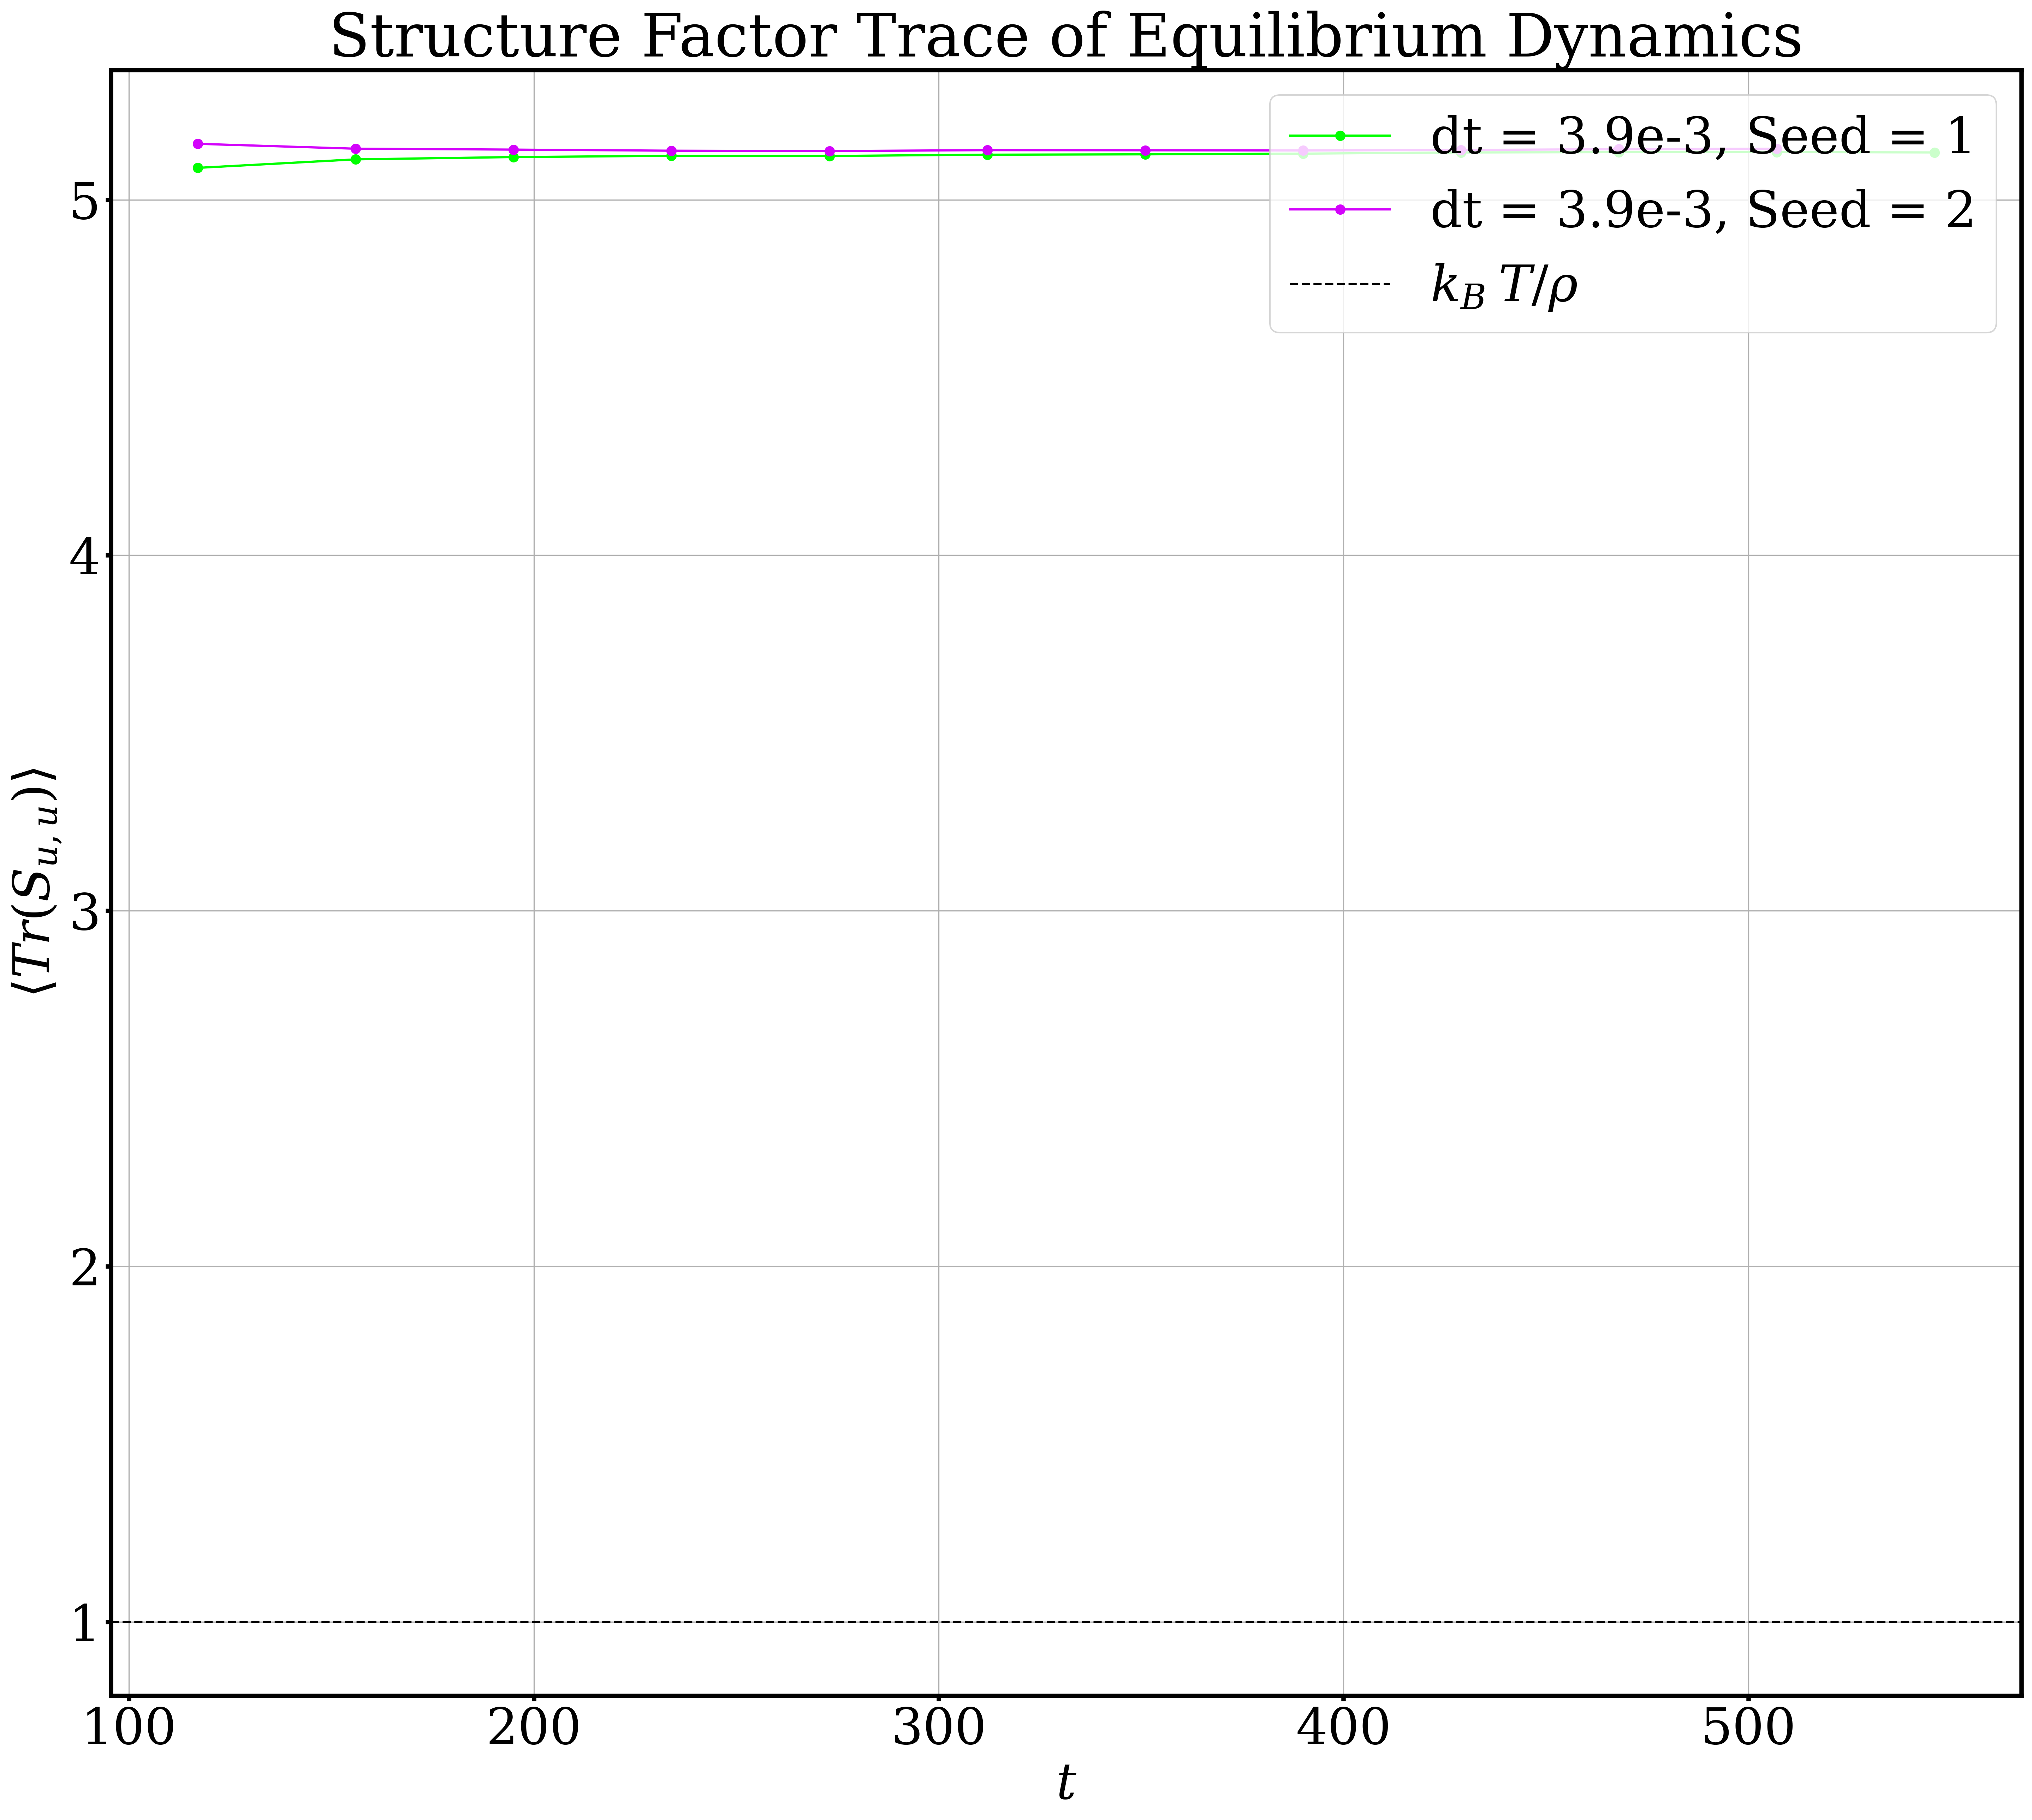

In [40]:
# plt.plot(df_trace['Time'], df_trace['Trace'] / np.square(Nx), c = "blue", label = r"$Tr(S_{u,u}) / N_x N_y$")
# plt.axhline(answer, label = r"$k_B \: T / \rho$", c = "black", ls = "--")
# plt.title(f'SF Trace $N_x$ = {Nx} and visc = 1e-4\n(incflo, use_tensor_solve = false, PPM_flux_limiter = False)')

plt.rcParams.update({'font.size': 34})
plt.figure(figsize=(20, 18), dpi = 300)
q = 0

for n in range(N_dt):
    for i in range(N_seeds):
        plt.plot(df_trace_list_arr[n][i]['Time'], (df_trace_list_arr[n][i]['Trace'] / np.square(Nx)) / answer, marker = markers[n], color = colors[q], label = f"dt = {dt_arr[n]}, Seed = {i+1}")
        q += 1


# plt.plot(df_trace_2['Time'], (df_trace_2['Trace'] / np.square(Nx)) / answer, c = "red", label = r"$Tr(S_{u,u}) / N_x N_y$")
# plt.plot(df_trace_3['Time'], (df_trace_3['Trace'] / np.square(Nx)) / answer, c = "green", label = r"$Tr(S_{u,u}) / N_x N_y$")
plt.axhline(answer / answer, label = r"$k_B \: T / \rho$", c = "black", ls = "--")
# plt.title(f'Structure Factor Trace $N_x$ = {Nx} and visc = 1e-4\n(incflo with WENO5, cell_depth = 1e-5, weighted fluxes)')
plt.title(f'Structure Factor Trace of Equilibrium Dynamics')
plt.grid(True) #, linestyle=':') #, alpha=0.6)

# plt.yscale('log')
# plt.ylim(bottom=3.65e-14)
plt.xlabel(r"$t$")
# plt.ylabel(r"$Tr(S_{u,u}) / N_x N_y$")
plt.ylabel(r"$\langle Tr(S_{u,u}) \rangle$")
# plt.legend()
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.legend(loc='upper right')
# plt.ylim([.967,1.001])
plt.tight_layout()
plt.show()
plt.close()



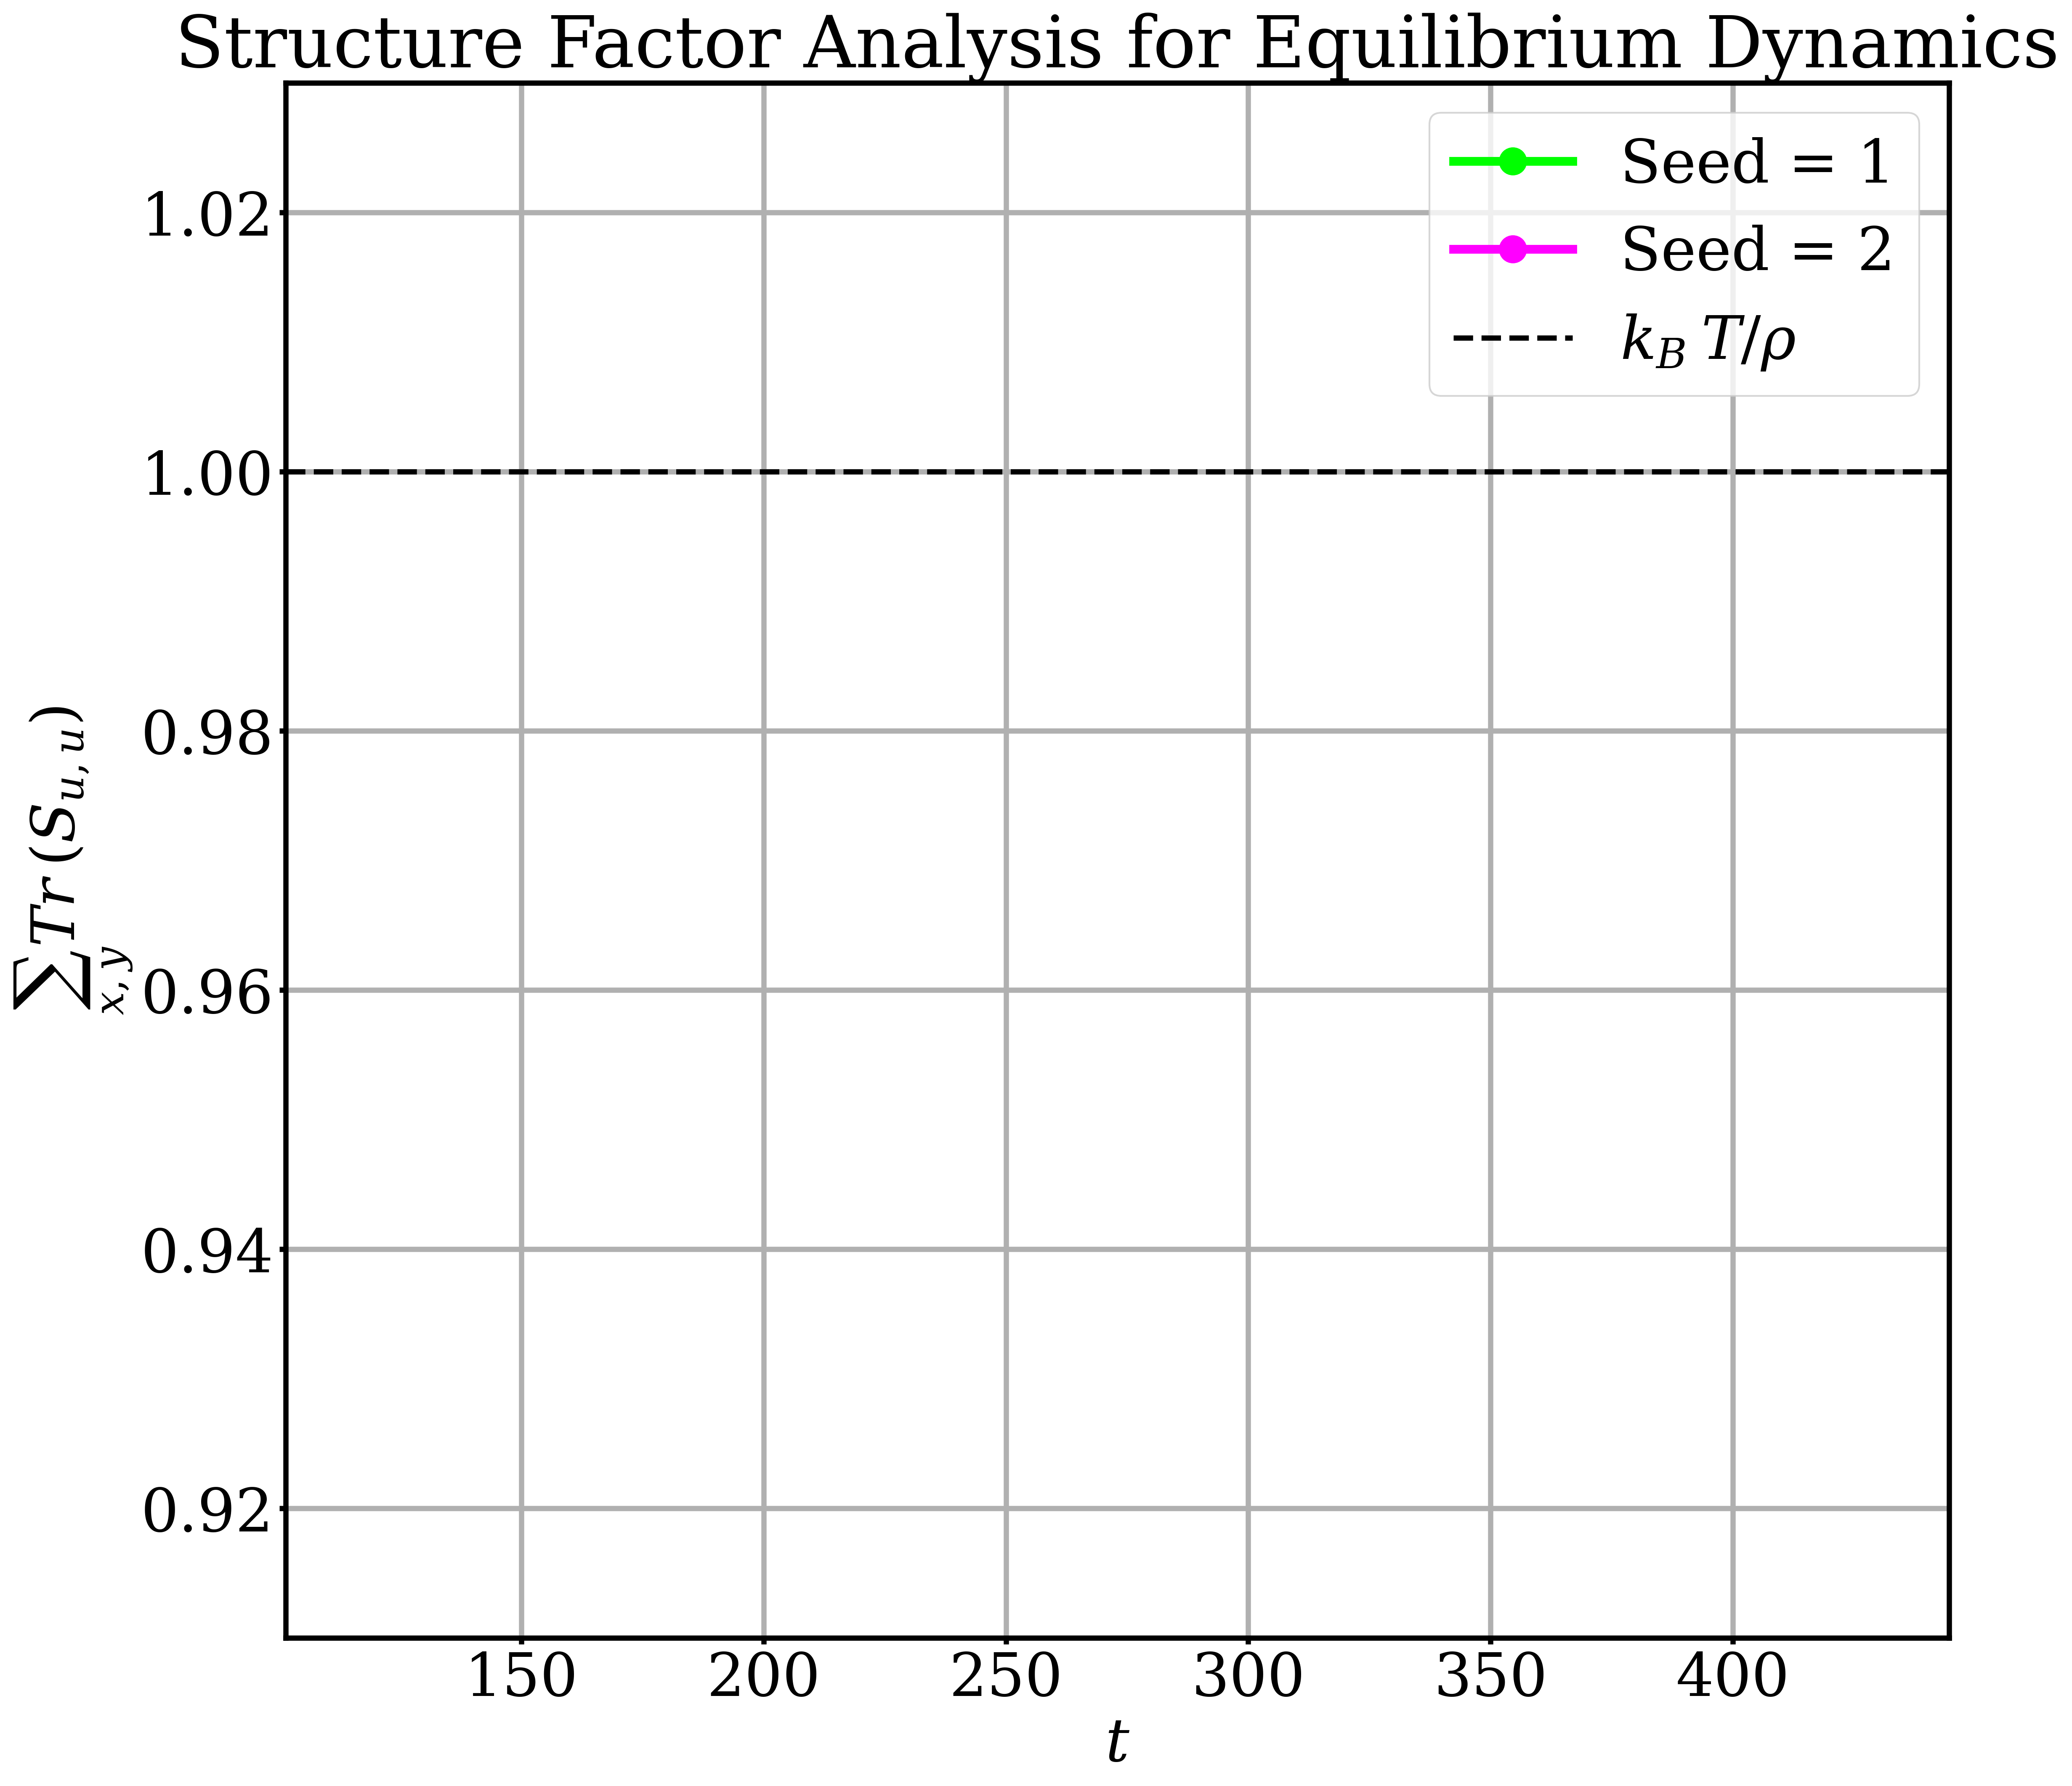

In [30]:
plt.rcParams.update({
    'font.size': 34,
    'axes.linewidth': 3,    
    'xtick.major.width': 3, 
    'ytick.major.width': 3,
    
    # Set standard text to Matplotlib's built-in serif font
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    
    # Automatically use the matching built-in serif math font
    'mathtext.fontset': 'dejavuserif'
})

plt.figure(figsize=(17, 16), dpi=300)
q = 0

for n in range(N_dt):
    for i in range(N_seeds):
        plt.plot(df_trace_list_arr[n][i]['Time'], 
                 (df_trace_list_arr[n][i]['Trace'] / np.square(Nx)) / answer, 
                 marker=markers[n], 
                 markersize=15,     
                 linewidth=5,       
                 color=colors[q], 
                 label=f"Seed = {i+1}")
                 # label=f"dt = {dt_arr[n]}, Seed = {i+1}")
        q += 1

plt.axhline(answer / answer, label=r"$k_B \: T / \rho$", c="black", ls="--", linewidth=3)

plt.title(f'Structure Factor Analysis for Equilibrium Dynamics')
plt.grid(True, linewidth=3)

plt.xlabel(r"$t$")
plt.ylabel(r"$\sum_{x,y} Tr \: (S_{u,u})$")
plt.legend(loc='upper right')
plt.ylim([.91, 1.03])
# plt.tight_layout()
plt.savefig('Graphs/structure_factor_summed_trace.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [31]:
# num_avg_steps = 10
# # recent_ts = ts[-num_avg_steps:]
# recent_ts = ts[33:43]

# # Initialize an empty 2D array to hold the averaged trace
# avg_trace_2d = np.zeros((Nx, Ny))

# count = 0
# for ds in recent_ts:
#     cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=[Nx, Ny, 1])
#     S_xx = np.array(cg['struct_fact_velx_velx'][:, :, 0].v)
#     S_yy = np.array(cg['struct_fact_vely_vely'][:, :, 0].v)
    
#     # Add the trace array for this timestep to the running total
#     avg_trace_2d += (S_xx + S_yy)
#     count += 1

# # Divide by the number of steps to get the average
# avg_trace_2d /= num_avg_steps
# # print(count)

ds_final = ts_list_arr[-1][0][-1]

# Extract the covering grid
cg = ds_final.covering_grid(level=0, left_edge=ds_final.domain_left_edge, dims=[Nx, Ny, 1])

# Extract S_xx and S_yy and sum them to get the Trace
S_xx = np.array(cg['struct_fact_velx_velx'][:, :, 0].v)
S_yy = np.array(cg['struct_fact_vely_vely'][:, :, 0].v)

trace_2d = S_xx + S_yy

# trace_2d = trace_2d / (Nx * Ny)

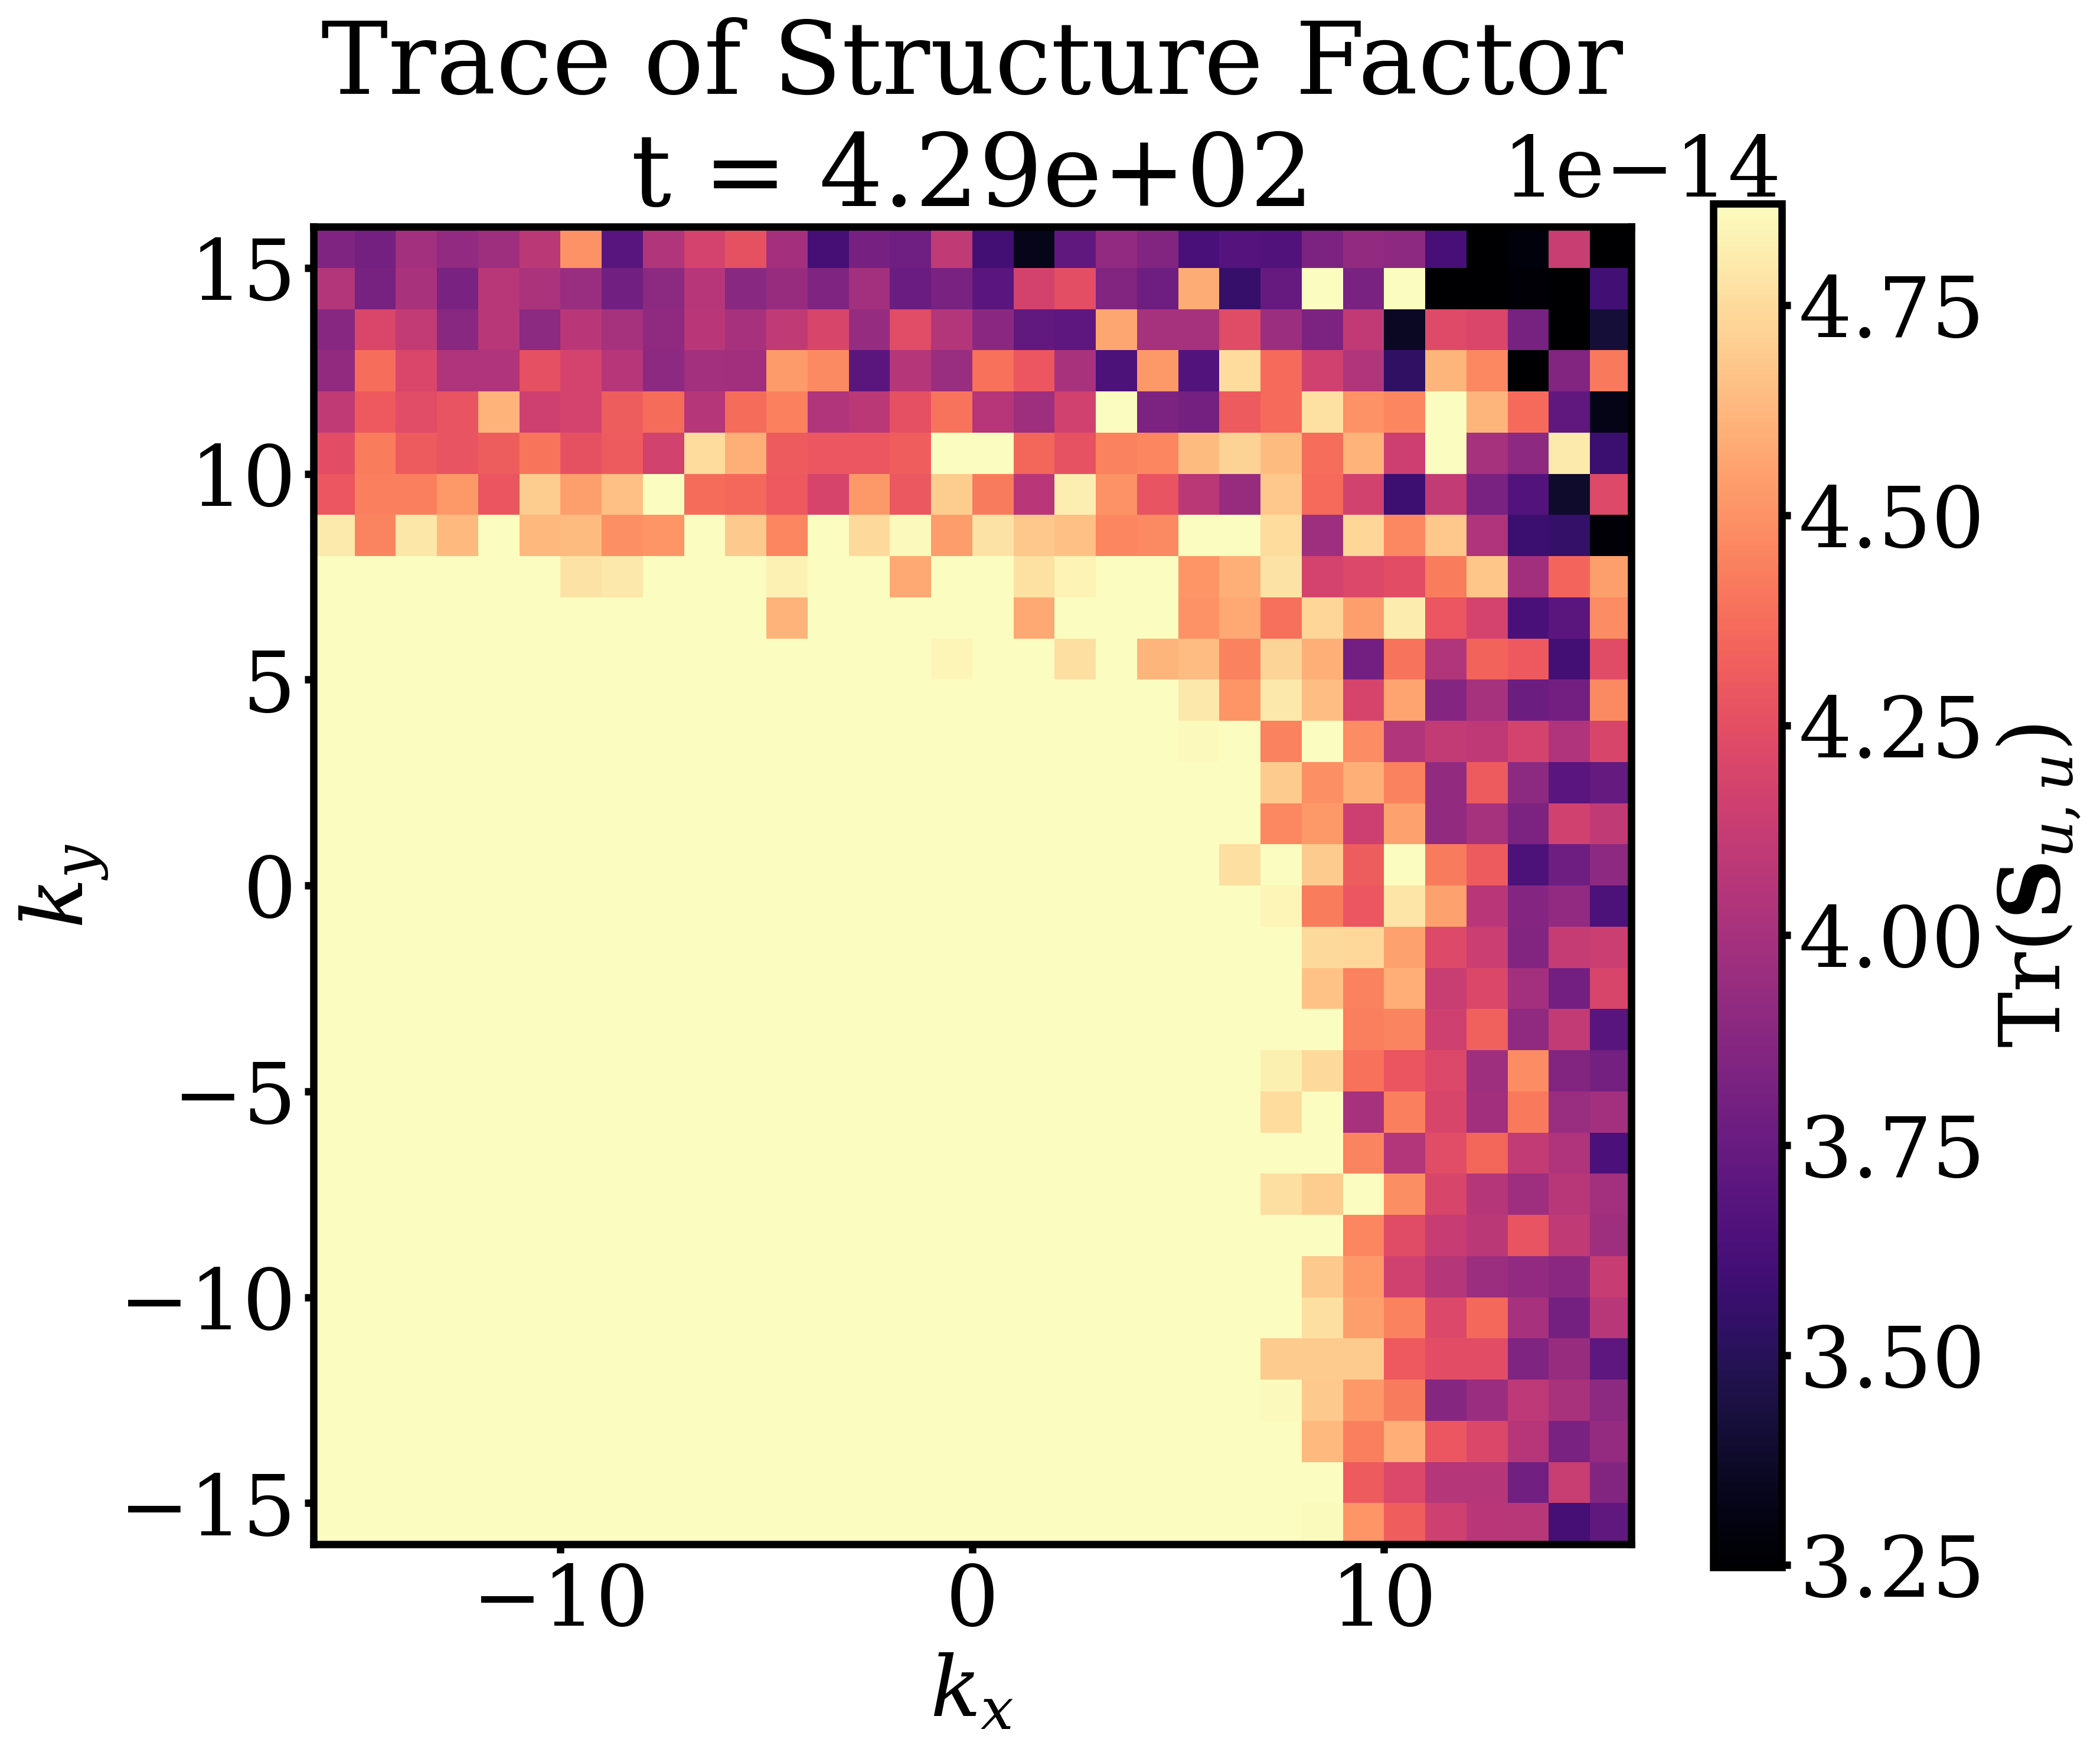

In [32]:
plt.rcParams.update({
    'font.size': 34,
    'axes.linewidth': 3,    
    'xtick.major.width': 3, 
    'ytick.major.width': 3,
    
    # Set standard text to Matplotlib's built-in serif font
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    
    # Automatically use the matching built-in serif math font
    'mathtext.fontset': 'dejavuserif'
})
# Plot the 2D Trace as a function of the wave vector (kx, ky)
plt.figure(figsize=(12, 10), dpi=300)

# Set extent to match k-space (centered at 0)
extent = [-Nx/2, Nx/2, -Ny/2, Ny/2]
# vmin = 1e-18
# vmax = 3e-13
# vmax = 6e-14
# vmax = trace_2d.max()
vmin = .2 * answer
vmax = 1.8 * answer
vmin = .8 * answer
vmax = 1.2 * answer
im = plt.imshow(trace_2d.T, origin='lower', extent=extent, cmap='magma', vmin = vmin, vmax = vmax)
# im = plt.imshow(trace_2d.T, origin='lower', extent=extent, cmap='magma', 
#                 norm=LogNorm(vmin=vmin, vmax=vmax))

plt.colorbar(im, label=r'$\text{Tr}(\mathbf{S}_{u,u})$')
# start_time = recent_ts[0].current_time.v
# end_time = recent_ts[-1].current_time.v
time = ds_final.current_time.v

# plt.title(f'Averaged Trace of Structure Factor (incflo)\n(t = {start_time:.2e} to {end_time:.2e})')
# plt.title(f'Run A Trace of Structure Factor at t = {time:.2e}\n(incflo with WENO5, visc = 1e-4, dt = {dt_arr[-4]})')
plt.title(f'Trace of Structure Factor\nt = {time:.2e}')

# plt.title(f'Averaged Trace of Structure Factor (Last {num_avg_steps} steps)')
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')
plt.savefig('Graphs/structure_factor_trace.png', dpi=300, bbox_inches='tight')
plt.show()

In [67]:
vmax

4.870929672e-14

In [ ]:
answer

## Energy spectrum

In [ ]:
# files = sorted(glob.glob('turb_vel*.txt'))
def read_in_spectrum_data(run_dir):
    spect_dir = os.path.join(run_dir, "turb_vel*.txt")
    files = sorted(glob.glob(spect_dir))
    dfs = []
    for f in files:
        num = int(re.search(r'turb_vel(\d+)\.txt', f).group(1))
        df = pd.read_csv(f, sep='\s+', header=None)
        df['file_num'] = num
        dfs.append(df)
    
    spect_data = pd.concat(dfs, ignore_index=True)
    return spect_data


spect_data_arr_list = []
for n in range(N_dt):
    spect_data_arr = []
    base_filename = base_filename_arr[n]
    for i in range(N_seeds):
        run_dir = f"{base_filename}_{i+1}00"
        spect_data = read_in_spectrum_data(run_dir)
        spect_data_arr.append(spect_data)

    spect_data_arr_list.append(spect_data_arr)

In [ ]:
# # run_dir_2 = "SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_2"
# spect_data_2 = read_in_spectrum_data(run_dir_2)

# # run_dir_3 = "SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_3"
# spect_data_3 = read_in_spectrum_data(run_dir_3)

In [ ]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(dpi=300)
file_nums = sorted(spect_data_arr[0]['file_num'].unique())
# colors = cm.coolwarm(np.linspace(0, 1, len(file_nums)))
norm = mcolors.Normalize(vmin=min(file_nums), vmax=max(file_nums))
cmap = cm.coolwarm

# for color, (num, group) in zip(colors, spect_data.groupby('file_num')):
#     ax.plot(group[0], group[1], color=color, label=num)
for num, group in spect_data_arr[0].groupby('file_num'):
    ax.plot(group[0], group[1], color=cmap(norm(num)))
    k_vals = group[0]
ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(k_vals, 5e-13*k_vals, 'k--', label=r'Ref: $k^{1}$')
ax.set_xlabel('k')
ax.set_ylabel('E(k)')
# ax.legend(title='file_num', loc='lower right')
ax.legend()
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='file_num')
plt.title("Run A Energy Spectrum")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

def plot_final_spect(spect_data, label):
    # Find the maximum file_num (the very last timestep saved)
    last_step = spect_data['file_num'].max()
    
    # Filter the dataframe to only grab the rows for that final timestep
    final_data = spect_data[spect_data['file_num'] == last_step]
    
    # Extract the k and E(k) arrays
    k_vals = final_data[0].values
    E_vals = final_data[1].values
    
    # Plot the single final line
    ax.plot(k_vals, E_vals, label=label)

    return k_vals, np.log10(E_vals)

# for n in range(N_dt):
n = -1
k_vals, E_vals_log = plot_final_spect(spect_data_arr_list[n][0], "Run A")
_, E_vals_log_2 = plot_final_spect(spect_data_arr_list[n][1], "Run B")
_, E_vals_log_3 = plot_final_spect(spect_data_arr_list[n][2], "Run C")

k_vals_log = np.log10(k_vals)

k_global = np.concatenate([k_vals_log, k_vals_log, k_vals_log])
E_global = np.concatenate([E_vals_log, E_vals_log_2, E_vals_log_3])
slope, intercept, r_value, _, _ = linregress(k_global, E_global)
r_squared = r_value**2
fit_E = (10**intercept) * (k_vals**slope)
ax.plot(k_vals, fit_E, color='red', linestyle='-', linewidth=2, label=f'Global Fit: slope={slope:.2f}, $R^2$={r_squared:.2f}')

# Reference line
ax.plot(k_vals, 5e-13 * k_vals, 'k--', label=r'Ref: $k^{1}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k')
ax.set_ylabel('E(k)')
ax.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.title("Energy Spectrum at Final Time Step")
plt.show()

In [ ]:
plt